# CelebA Attribute Analysis

Analyse every CelebA attribute: how many **smile** vs **non-smile** images fall under each attribute class.
Used to design OOD certification subsets (50 smile + 50 non-smile per attribute).

In [1]:
import sys, os, random
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# ── Academic style 
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.labelsize':    12,
    'axes.titlesize':    13,
    'legend.fontsize':   10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   10,
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

PALETTE = {'smile': '#1b7837', 'no_smile': '#762a83'}

# ── Paths 
CELEBA_ROOT = Path("/BS/databases08/CelebA")
ATTR_FILE   = CELEBA_ROOT / "Anno" / "list_attr_celeba.txt"

TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
SPLIT_SEED  = 73

print("Attribute file exists:", ATTR_FILE.exists())

Attribute file exists: True


## 1. Load Full Attribute Table

In [2]:
def load_celeba_attrs(attr_path):
    lines = [l.strip() for l in attr_path.read_text().splitlines() if l.strip()]
    attr_names = lines[1].split()
    rows = []
    for line in lines[2:]:
        parts = line.split()
        rows.append([parts[0]] + [int(v) for v in parts[1:]])
    df = pd.DataFrame(rows, columns=["filename"] + attr_names)
    for col in attr_names:
        df[col] = (df[col] == 1).astype(int)
    return df

def assign_splits(df, train_ratio, val_ratio, seed):
    filenames = df["filename"].tolist()
    rng = random.Random(seed)
    shuffled = list(filenames)
    rng.shuffle(shuffled)
    n_train = int(len(shuffled) * train_ratio)
    n_val   = int(len(shuffled) * val_ratio)
    split_map = (
        {f: "train" for f in shuffled[:n_train]}
        | {f: "val"   for f in shuffled[n_train:n_train + n_val]}
        | {f: "test"  for f in shuffled[n_train + n_val:]}
    )
    df = df.copy()
    df["split"] = df["filename"].map(split_map)
    return df

df = load_celeba_attrs(ATTR_FILE)
df = assign_splits(df, TRAIN_RATIO, VAL_RATIO, SPLIT_SEED)
ATTR_COLS = [c for c in df.columns if c not in ("filename", "split")]
df_test   = df[df["split"] == "test"].copy()
df_train   = df[df["split"] == "train"].copy()
print(f"Total: {len(df):,}  |  train: {(df.split=='train').sum():,}  "
      f"val: {(df.split=='val').sum():,}  test: {(df.split=='test').sum():,}")

Total: 202,599  |  train: 162,079  val: 20,259  test: 20,261


## 2. Per-Attribute Smile Counts (Test Split)

In [3]:
def attr_smile_table(df_sub, label=""):
    total = len(df_sub)
    records = []
    for attr in ATTR_COLS:
        sub = df_sub[df_sub[attr] == 1]
        n_attr   = len(sub)
        n_smile  = int(sub["Smiling"].sum())
        n_nsmile = n_attr - n_smile
        feasible = (n_smile >= 50) and (n_nsmile >= 50)
        records.append({
            "Attribute":            attr,
            "Attr=1 count":         n_attr,
            "% of split":           round(100 * n_attr / total, 1),
            "Smile":                n_smile,
            "Non-smile":            n_nsmile,
            "Smile %":              round(100 * n_smile / n_attr, 1) if n_attr else 0,
            "OOD feasible":         feasible,
        })
    return pd.DataFrame(records).sort_values("Attr=1 count", ascending=False).reset_index(drop=True)

tbl_test = attr_smile_table(df_test, "test")
feasible_attrs = tbl_test[tbl_test["OOD feasible"]].copy()
print(f"OOD-feasible attributes: {len(feasible_attrs)}")
display(tbl_test.style.format({
    "Attr=1 count": "{:,}", "Smile": "{:,}", "Non-smile": "{:,}",
    "% of split": "{:.1f}%", "Smile %": "{:.1f}%"
}))

OOD-feasible attributes: 39


,Attribute,Attr=1 count,% of split,Smile,Non-smile,Smile %,OOD feasible
0,No_Beard,"16,943",83.6%,"8,632","8,311",50.9%,True
1,Young,"15,558",76.8%,"7,391","8,167",47.5%,True
2,Attractive,"10,265",50.7%,"5,783","4,482",56.3%,True
3,Smiling,"9,793",48.3%,"9,793",0,100.0%,False
4,Mouth_Slightly_Open,"9,783",48.3%,"7,427","2,356",75.9%,True
5,Wearing_Lipstick,"9,515",47.0%,"5,588","3,927",58.7%,True
6,High_Cheekbones,"9,275",45.8%,"7,961","1,314",85.8%,True
7,Male,"8,452",41.7%,"3,370","5,082",39.9%,True
8,Heavy_Makeup,"7,808",38.5%,"4,697","3,111",60.2%,True
9,Wavy_Hair,"6,450",31.8%,"3,528","2,922",54.7%,True


## 3. Figure 1 — Smile vs Non-smile Count per Attribute (Test Split)

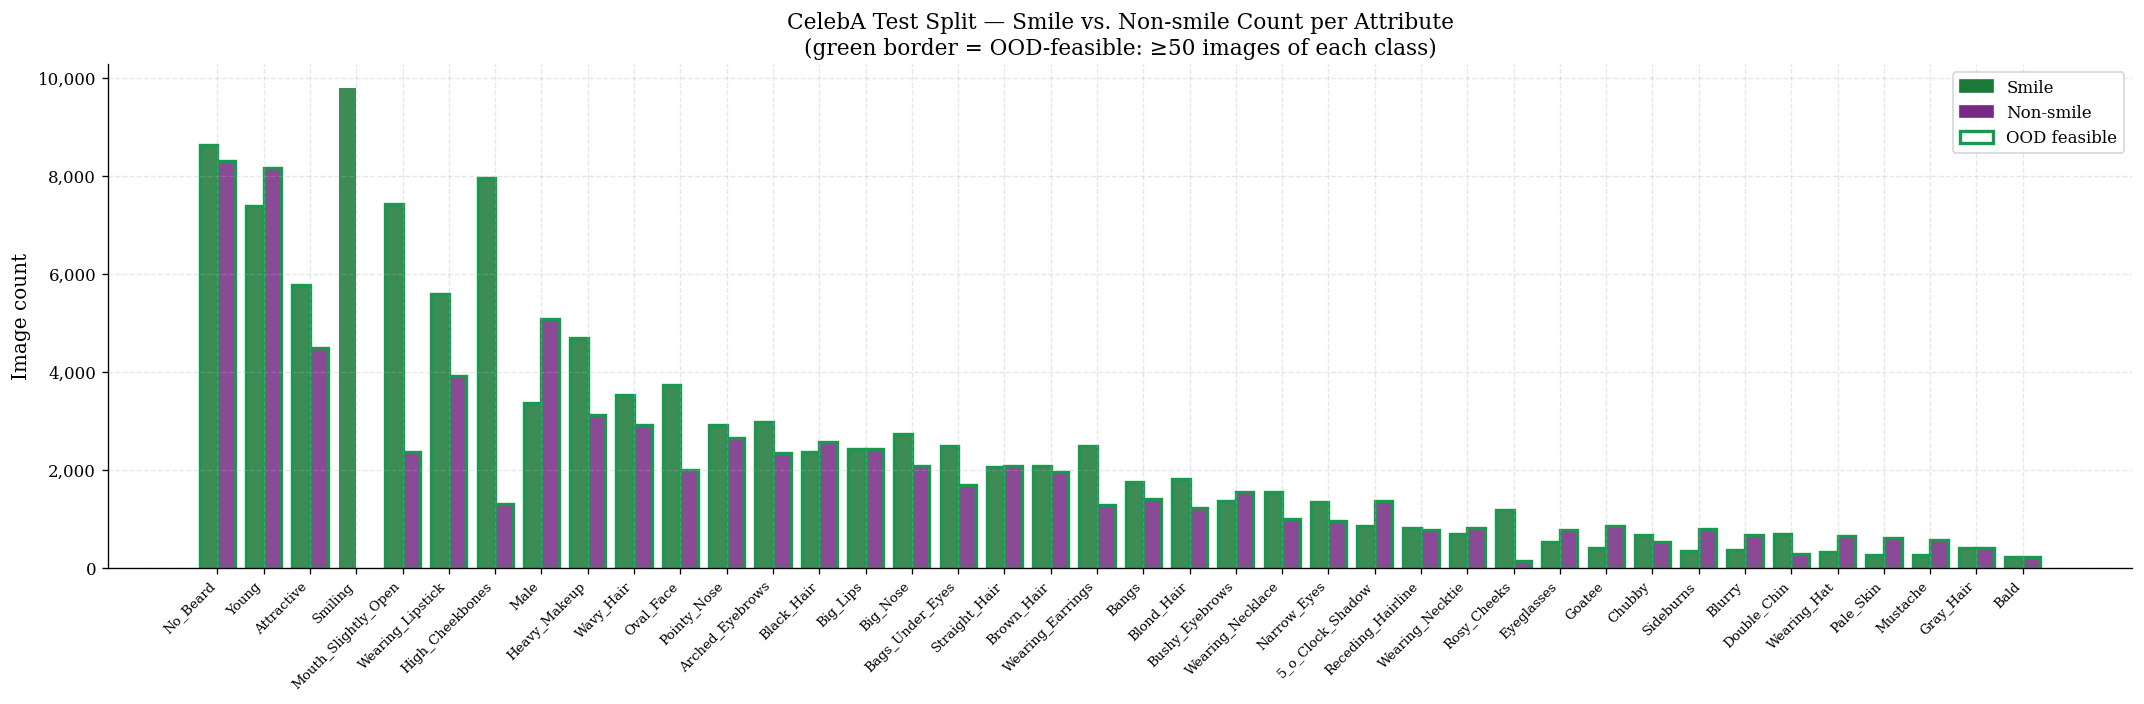

In [4]:
fig, ax = plt.subplots(figsize=(18, 6))

attrs  = tbl_test["Attribute"].tolist()
smiles = tbl_test["Smile"].tolist()
nsmile = tbl_test["Non-smile"].tolist()
feasible_flags = tbl_test["OOD feasible"].tolist()

x = np.arange(len(attrs))
w = 0.38
ax.bar(x - w/2, smiles, w, label="Smile",     color=PALETTE['smile'],    alpha=0.85)
ax.bar(x + w/2, nsmile, w, label="Non-smile", color=PALETTE['no_smile'], alpha=0.85)

# mark OOD-feasible with green border
for i, f in enumerate(feasible_flags):
    if f:
        ax.bar(x[i] - w/2, smiles[i], w, color='none', edgecolor='#1a9850', linewidth=2)
        ax.bar(x[i] + w/2, nsmile[i], w, color='none', edgecolor='#1a9850', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(attrs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Image count")
ax.set_title("CelebA Test Split — Smile vs. Non-smile Count per Attribute\n"
             "(green border = OOD-feasible: \u226550 images of each class)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(handles=[
    mpatches.Patch(color=PALETTE['smile'],    label='Smile'),
    mpatches.Patch(color=PALETTE['no_smile'], label='Non-smile'),
    mpatches.Patch(facecolor='none', edgecolor='#1a9850', linewidth=2, label='OOD feasible'),
])
plt.tight_layout()
plt.savefig("fig_attr_smile_counts.pdf", bbox_inches='tight')
plt.show()

## 4. Figure 2 — Smile Imbalance Ranking

/BS/dniazi_thesis/work/miniforge3_new/envs/smoothing/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/BS/dniazi_thesis/work/miniforge3_new/envs/smoothing/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/BS/dniazi_thesis/work/miniforge3_new/envs/smoothing/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


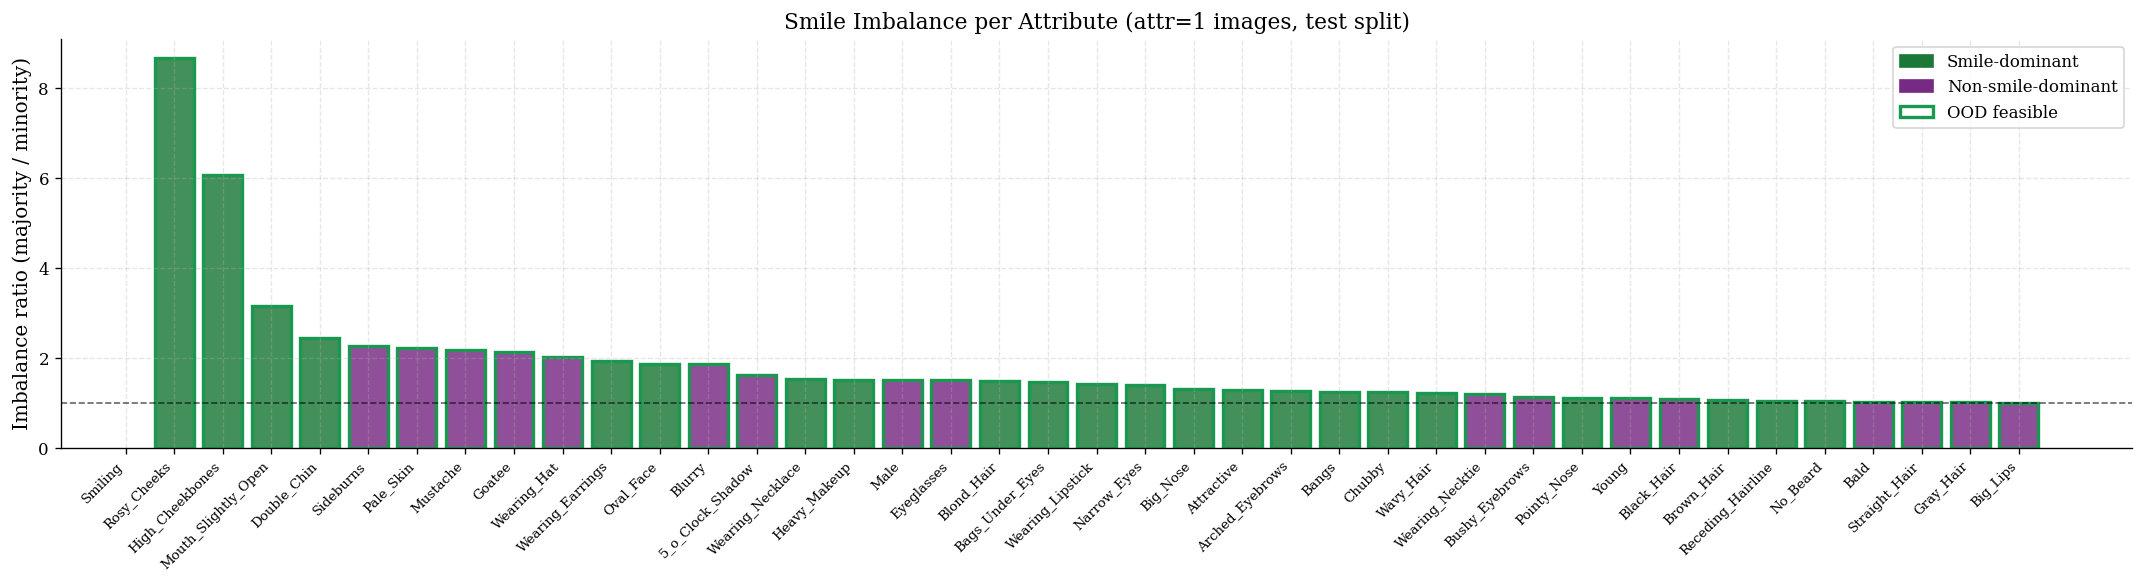

,Attribute,Smile,Non-smile,Smile %,Imbalance ratio,Dominant,OOD feasible
29,Rosy_Cheeks,"1,178",136,89.6%,8.66,smile,True
19,High_Cheekbones,"7,961","1,314",85.8%,6.06,smile,True
21,Mouth_Slightly_Open,"7,427","2,356",75.9%,3.15,smile,True
14,Double_Chin,697,284,71.0%,2.45,smile,True
30,Sideburns,354,801,30.6%,2.26,non-smile,True
26,Pale_Skin,272,601,31.2%,2.21,non-smile,True
22,Mustache,263,571,31.5%,2.17,non-smile,True
16,Goatee,402,860,31.9%,2.14,non-smile,True
35,Wearing_Hat,322,648,33.2%,2.01,non-smile,True
34,Wearing_Earrings,"2,494","1,287",66.0%,1.94,smile,True


In [5]:
imb_records = []
for attr in ATTR_COLS:
    sub = df_test[df_test[attr] == 1]
    n = len(sub)
    if n == 0: continue
    ns  = int(sub["Smiling"].sum())
    nns = n - ns
    minority = min(ns, nns)
    majority = max(ns, nns)
    ratio    = majority / minority if minority > 0 else np.inf
    imb_records.append({
        "Attribute":      attr,
        "Smile":          ns,
        "Non-smile":      nns,
        "Smile %":        round(100*ns/n, 1),
        "Imbalance ratio": round(ratio, 2),
        "Dominant":       "smile" if ns > nns else "non-smile",
        "OOD feasible":   (ns >= 50) and (nns >= 50),
    })
imb_df = pd.DataFrame(imb_records).sort_values("Imbalance ratio", ascending=False)

fig, ax = plt.subplots(figsize=(18, 5))
colors = [PALETTE['smile'] if d == 'smile' else PALETTE['no_smile']
          for d in imb_df['Dominant']]
ax.bar(imb_df['Attribute'], imb_df['Imbalance ratio'], color=colors, alpha=0.82, edgecolor='white')

for i, (f, r) in enumerate(zip(imb_df['OOD feasible'], imb_df['Imbalance ratio'])):
    if f:
        ax.bar(imb_df['Attribute'].iloc[i], r, color='none', edgecolor='#1a9850', linewidth=2)

ax.axhline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xticks(range(len(imb_df)))
ax.set_xticklabels(imb_df['Attribute'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Imbalance ratio (majority / minority)")
ax.set_title("Smile Imbalance per Attribute (attr=1 images, test split)")
ax.legend(handles=[
    mpatches.Patch(color=PALETTE['smile'],    label='Smile-dominant'),
    mpatches.Patch(color=PALETTE['no_smile'], label='Non-smile-dominant'),
    mpatches.Patch(facecolor='none', edgecolor='#1a9850', linewidth=2, label='OOD feasible'),
])
plt.tight_layout()
plt.savefig("fig_attr_imbalance.pdf", bbox_inches='tight')
plt.show()

display(imb_df[imb_df['OOD feasible']].style.format({
    'Smile':'{:,}', 'Non-smile':'{:,}', 'Smile %':'{:.1f}%', 'Imbalance ratio':'{:.2f}'
}))

## 5. Figure 3 — Smile % for OOD-Feasible Attributes (Horizontal Bar)

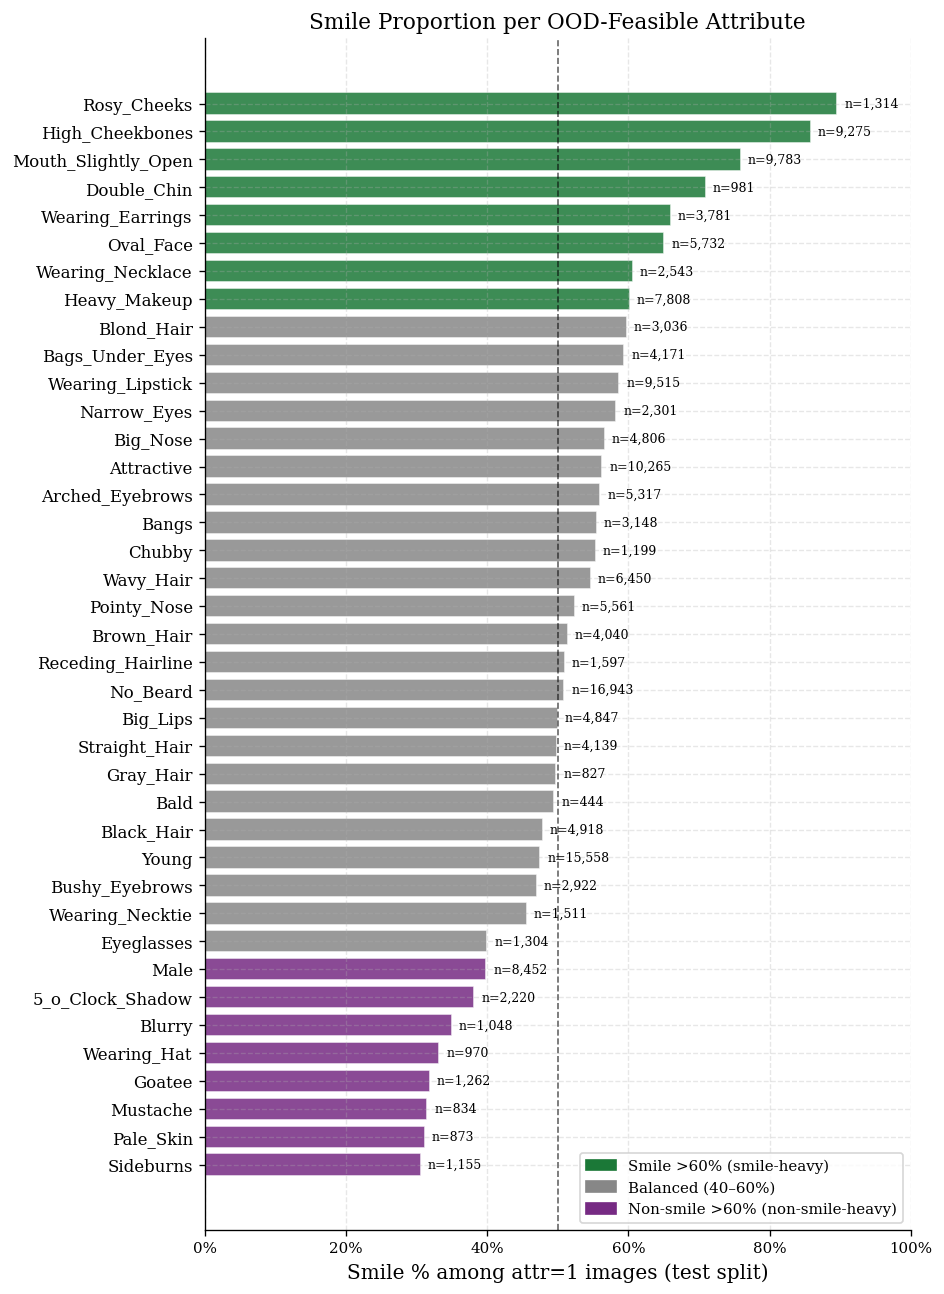

In [6]:
# Show smile % for each OOD-feasible attribute — sorted ascending
# Red zone < 40%, green zone > 60%, neutral otherwise
feas = feasible_attrs.sort_values("Smile %")
pcts = feas["Smile %"].values
labels = feas["Attribute"].values
colors_pct = ['#762a83' if p < 40 else '#1b7837' if p > 60 else '#878787' for p in pcts]

fig, ax = plt.subplots(figsize=(8, max(6, len(feas)*0.28)))
bars = ax.barh(labels, pcts, color=colors_pct, alpha=0.85, edgecolor='white')
ax.axvline(50, color='black', linewidth=1, linestyle='--', alpha=0.6, label='50% balanced')
ax.set_xlabel("Smile % among attr=1 images (test split)")
ax.set_title("Smile Proportion per OOD-Feasible Attribute")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(handles=[
    mpatches.Patch(color='#1b7837', label='Smile >60% (smile-heavy)'),
    mpatches.Patch(color='#878787', label='Balanced (40–60%)'),
    mpatches.Patch(color='#762a83', label='Non-smile >60% (non-smile-heavy)'),
], loc='lower right', fontsize=9)

# annotate count
for bar, (_, row) in zip(bars, feas.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"n={row['Attr=1 count']:,}", va='center', fontsize=7.5)
plt.tight_layout()
plt.savefig("fig_attr_smile_pct.pdf", bbox_inches='tight')
plt.show()

# 5.1 Correlation Between Attributes


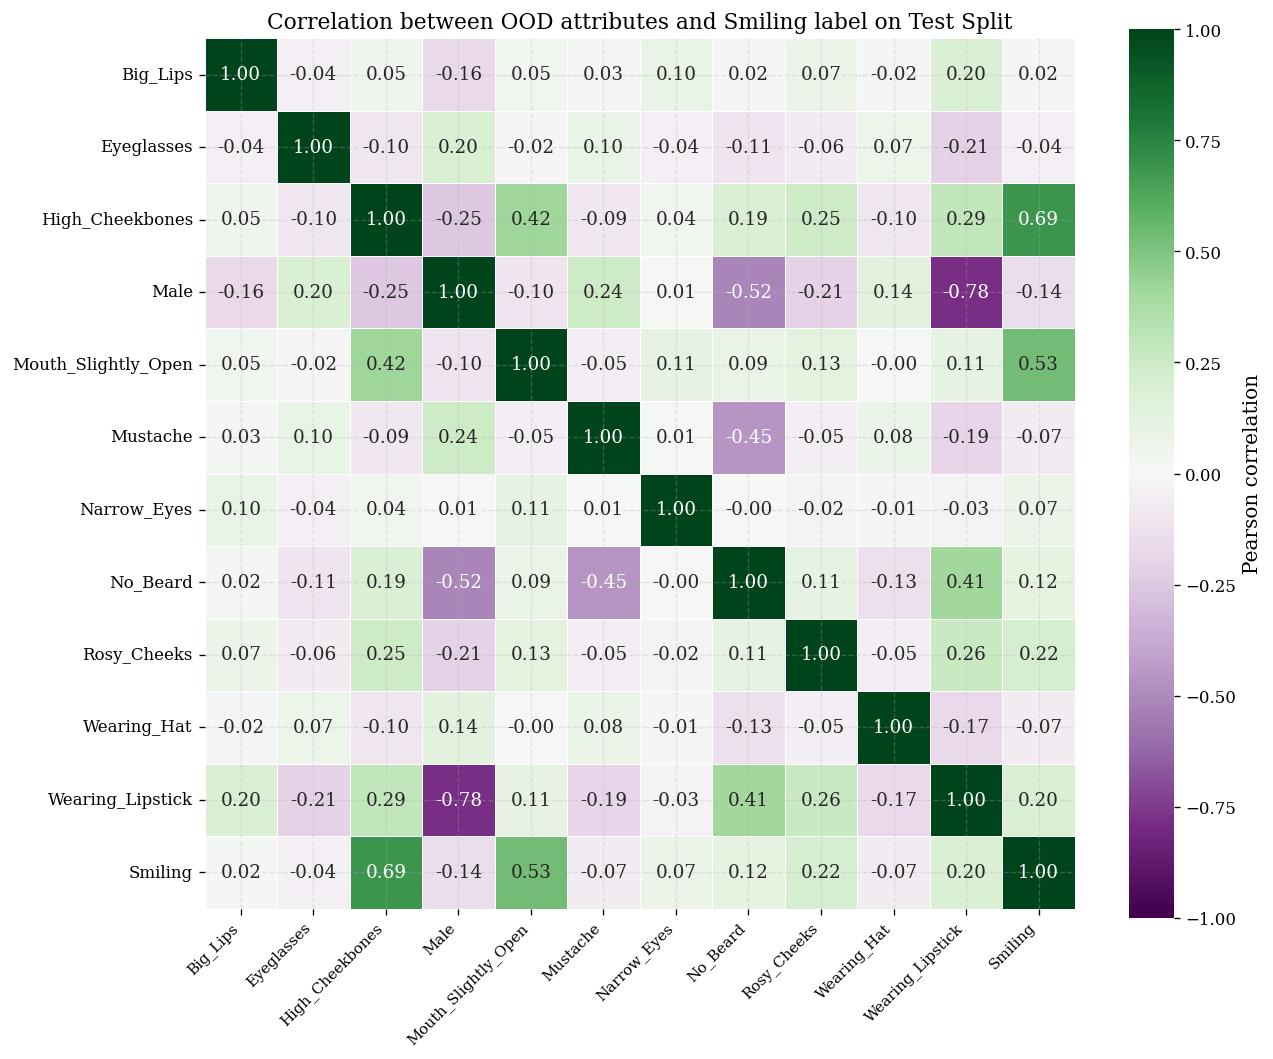

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ood_attrs = [
    "Big_Lips",
    "Eyeglasses",
    "High_Cheekbones",
    "Male",
    "Mouth_Slightly_Open",
    "Mustache",
    "Narrow_Eyes",
    "No_Beard",
    "Rosy_Cheeks",
    "Wearing_Hat",
    "Wearing_Lipstick",
]

cols = ood_attrs + ["Smiling"]

# make sure attributes are 0/1, not -1/1
corr_df = df_test[cols].copy()
corr_df = corr_df.replace(-1, 0)

corr = corr_df.corr(method="pearson")

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="PRGn",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Correlation between OOD attributes and Smiling label on Test Split")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("ood_attribute_correlation_heatmap.pdf", bbox_inches="tight")
plt.show()

In [23]:
ood_attrs = [
    "No_Beard",
    "Mouth_Slightly_Open",
    "Wearing_Lipstick",
    "High_Cheekbones",
    "Male",
    "Big_Lips",
    "Narrow_Eyes",
    "Rosy_Cheeks",
    "Eyeglasses",
    "Wearing_Hat",
    "Mustache",
]

rows = []

N = len(df_test)

for attr in ood_attrs:

    # % of dataset having attr=1
    pct_dataset = 100 * (df_test[attr] == 1).mean()

    # Smile rate among attr=1 images
    smile_rate = 100 * df_test[df_test[attr] == 1]["Smiling"].mean()

    # Correlation with smile
    corr_smile = corr.loc[attr, "Smiling"]

    rows.append({
        "Attribute": attr,
        "% Dataset": pct_dataset,
        "Smile % | attr=1": smile_rate,
        "Corr(attr, Smile)": corr_smile,
    })

summary_df = (
    pd.DataFrame(rows)
    .sort_values("Smile % | attr=1", ascending=False)
)

display(summary_df.round(2))

,Attribute,% Dataset,Smile % | attr=1,"Corr(attr, Smile)"
7,Rosy_Cheeks,6.49,89.65,0.22
3,High_Cheekbones,45.78,85.83,0.69
1,Mouth_Slightly_Open,48.28,75.92,0.53
2,Wearing_Lipstick,46.96,58.73,0.20
6,Narrow_Eyes,11.36,58.32,0.07
0,No_Beard,83.62,50.95,0.12
5,Big_Lips,23.92,49.97,0.02
8,Eyeglasses,6.44,39.95,-0.04
4,Male,41.72,39.87,-0.14
9,Wearing_Hat,4.79,33.20,-0.07


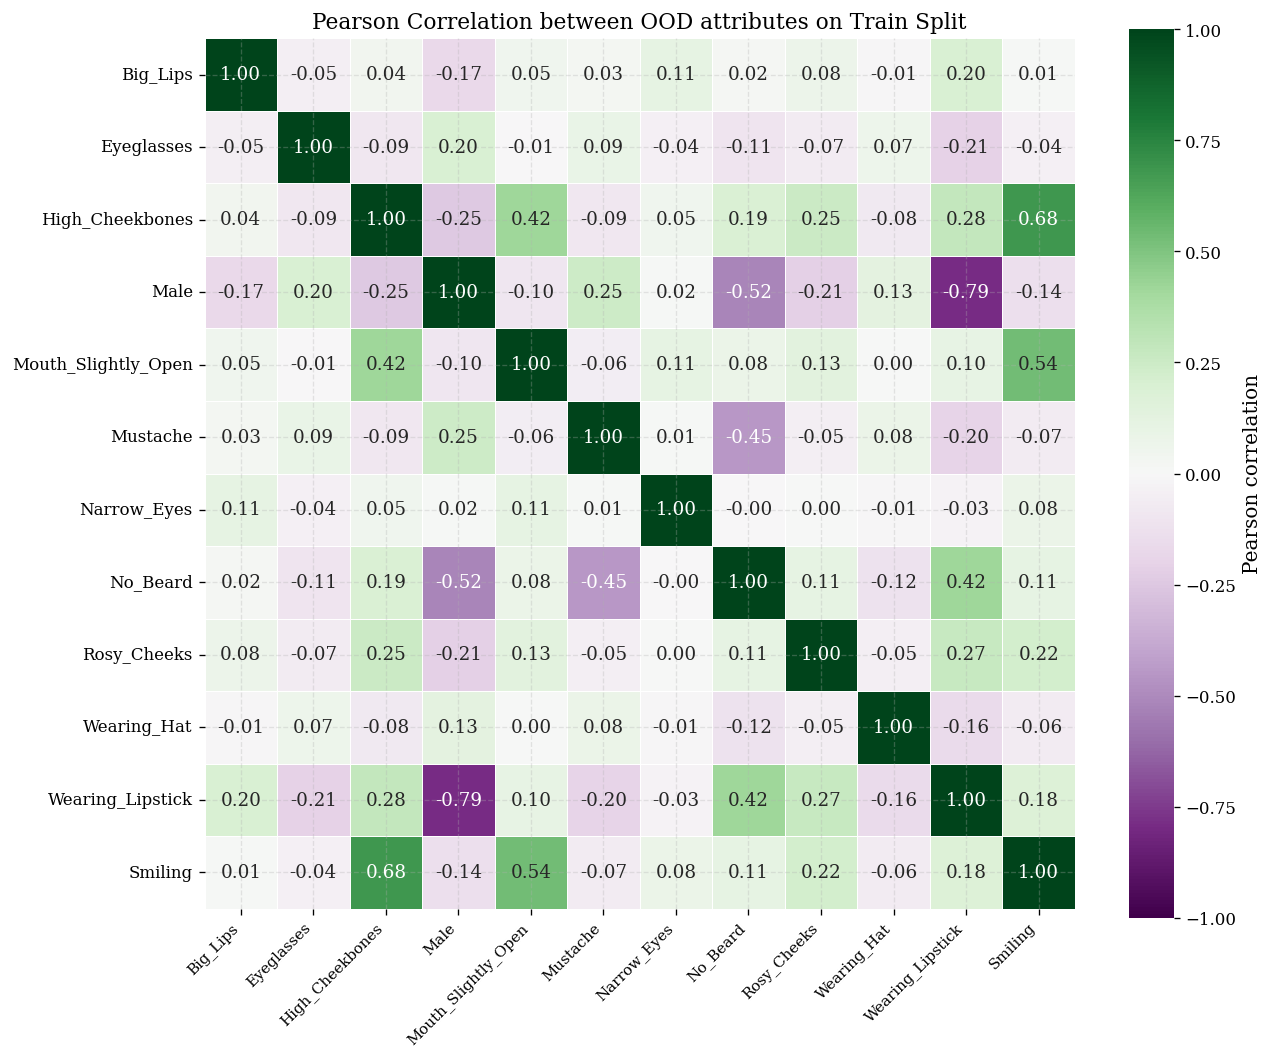

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ood_attrs = [
    "Big_Lips",
    "Eyeglasses",
    "High_Cheekbones",
    "Male",
    "Mouth_Slightly_Open",
    "Mustache",
    "Narrow_Eyes",
    "No_Beard",
    "Rosy_Cheeks",
    "Wearing_Hat",
    "Wearing_Lipstick",
]

cols = ood_attrs + ["Smiling"]

# make sure attributes are 0/1, not -1/1
corr_df = df_train[cols].copy()
corr_df = corr_df.replace(-1, 0)

corr = corr_df.corr(method="pearson")

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="PRGn",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Pearson Correlation between OOD attributes on Train Split")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("ood_attribute_correlation_heatmap.pdf", bbox_inches="tight")
plt.show()

In [21]:
ood_attrs = [
    "No_Beard",
    "Mouth_Slightly_Open",
    "Wearing_Lipstick",
    "High_Cheekbones",
    "Male",
    "Big_Lips",
    "Narrow_Eyes",
    "Rosy_Cheeks",
    "Eyeglasses",
    "Wearing_Hat",
    "Mustache",
]

rows = []

N = len(df_test)

for attr in ood_attrs:

    # % of dataset having attr=1
    pct_dataset = 100 * (df_test[attr] == 1).mean()

    # Smile rate among attr=1 images
    smile_rate = 100 * df_test[df_test[attr] == 1]["Smiling"].mean()

    # Correlation with smile
    corr_smile = corr.loc[attr, "Smiling"]

    rows.append({
        "Attribute": attr,
        "% Dataset": pct_dataset,
        "Smile % | attr=1": smile_rate,
        "Corr(attr, Smile)": corr_smile,
    })

summary_df = (
    pd.DataFrame(rows)
    .sort_values("Smile % | attr=1", ascending=False)
)

display(summary_df.round(2))

,Attribute,% Dataset,Smile % | attr=1,"Corr(attr, Smile)"
7,Rosy_Cheeks,6.49,89.65,0.22
3,High_Cheekbones,45.78,85.83,0.68
1,Mouth_Slightly_Open,48.28,75.92,0.54
2,Wearing_Lipstick,46.96,58.73,0.18
6,Narrow_Eyes,11.36,58.32,0.08
0,No_Beard,83.62,50.95,0.11
5,Big_Lips,23.92,49.97,0.01
8,Eyeglasses,6.44,39.95,-0.04
4,Male,41.72,39.87,-0.14
9,Wearing_Hat,4.79,33.20,-0.06


## 6. Smile Rate (Top OOD Attributes)

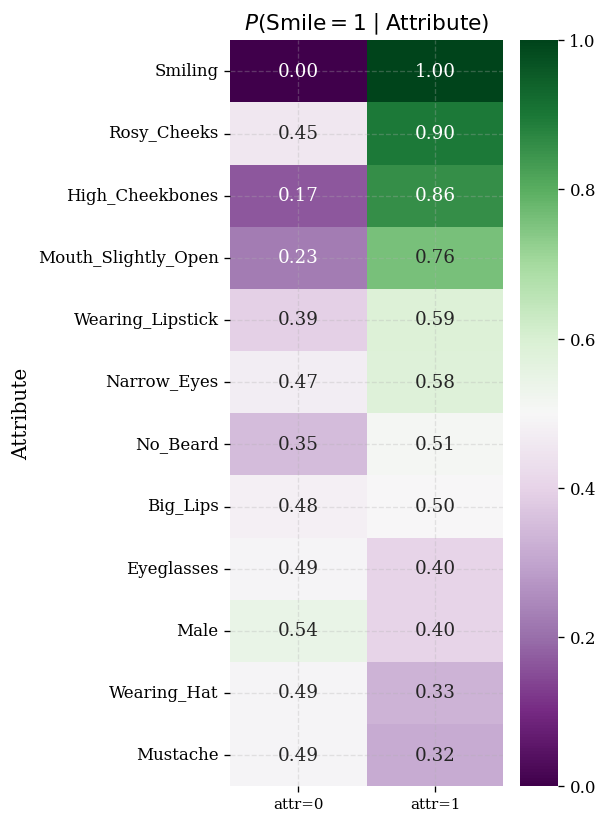

In [16]:
ood_attrs = [
    "No_Beard",
    "Mouth_Slightly_Open",
    "Wearing_Lipstick",
    "High_Cheekbones",
    "Male",
    "Big_Lips",
    "Narrow_Eyes",
    "Rosy_Cheeks",
    "Eyeglasses",
    "Wearing_Hat",
    "Mustache",
    "Smiling"
]

rows = []

for attr in ood_attrs:
    smile_if_1 = df_test[df_test[attr] == 1]["Smiling"].mean()
    smile_if_0 = df_test[df_test[attr] == 0]["Smiling"].mean()

    rows.append({
        "Attribute": attr,
        "attr=0": smile_if_0,
        "attr=1": smile_if_1,
    })

heat_df = (
    pd.DataFrame(rows)
    .sort_values("attr=1", ascending=False)
    .set_index("Attribute")
)

plt.figure(figsize=(5,7))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".2f",
    cmap="PRGn",
    vmin=0,
    vmax=1
)
plt.title(r"$P(\mathrm{Smile}=1 \mid \mathrm{Attribute})$")
plt.tight_layout()
plt.show()

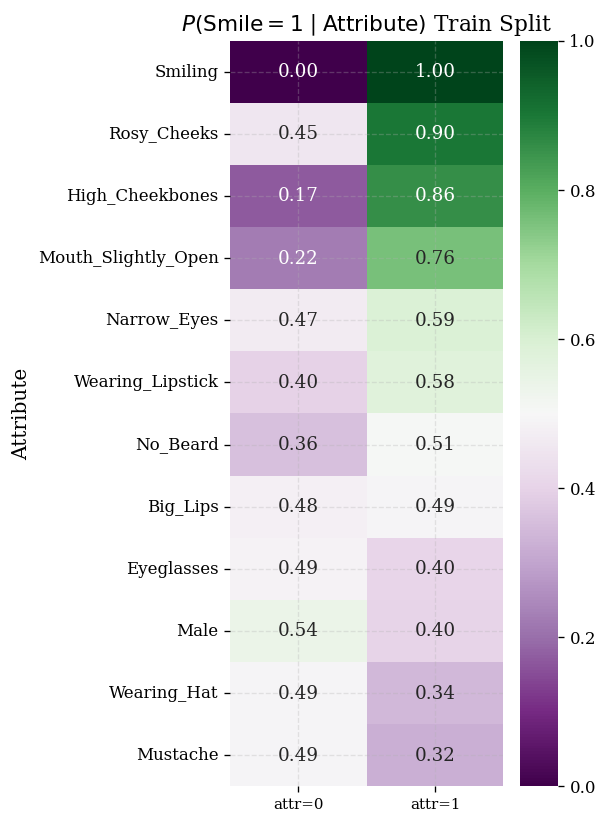

In [19]:
ood_attrs = [
    "No_Beard",
    "Mouth_Slightly_Open",
    "Wearing_Lipstick",
    "High_Cheekbones",
    "Male",
    "Big_Lips",
    "Narrow_Eyes",
    "Rosy_Cheeks",
    "Eyeglasses",
    "Wearing_Hat",
    "Mustache",
    "Smiling"
]

rows = []

for attr in ood_attrs:
    smile_if_1 = df_train[df_train[attr] == 1]["Smiling"].mean()
    smile_if_0 = df_train[df_train[attr] == 0]["Smiling"].mean()

    rows.append({
        "Attribute": attr,
        "attr=0": smile_if_0,
        "attr=1": smile_if_1,
    })

heat_df = (
    pd.DataFrame(rows)
    .sort_values("attr=1", ascending=False)
    .set_index("Attribute")
)

plt.figure(figsize=(5,7))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".2f",
    cmap="PRGn",
    vmin=0,
    vmax=1
)
plt.title(r"$P(\mathrm{Smile}=1 \mid \mathrm{Attribute})$ Train Split")
plt.tight_layout()
plt.show()

## 7. Summary Table for Paper

## 8. OOD Subset Size Analysis — Equal & Balanced Subsets

For fair comparison across all OOD attributes we need:
- **Training (attr=0):** same N images, ~50% smile
- **Test/Eval (attr=1):** same N images, ~50% smile

The  N is: `min over all attrs of min(smile_count, nonsmile_count)` in each split.

In [5]:
## 8. OOD Subset Size Analysis — Equal & Balanced Subsets
# For each OOD attribute, compute:
#   train_attr0: images in train with attr=0  → classifier trains on these
#   test_attr1:  images in test  with attr=1  → eval on these
# For each group, find how many balanced (smile=0/smile=1) samples we can draw.
# Recommended N = min across all attrs so all experiments use identical counts.

OOD_ATTRS = [
    "Wearing_Hat", "Eyeglasses", "Male", "Wearing_Lipstick",
    "Mouth_Slightly_Open", "High_Cheekbones", "Big_Lips",
    "Narrow_Eyes", "Mustache", "No_Beard", "Rosy_Cheeks",
]

rows = []
for attr in OOD_ATTRS:
    # ── Train: attr=0 ──────────────────────────────────────────────────
    tr0      = df_train[df_train[attr] == 0]
    tr0_s    = int((tr0["Smiling"] == 1).sum())
    tr0_ns   = int((tr0["Smiling"] == 0).sum())
    tr0_bal  = min(tr0_s, tr0_ns)   # max balanced pairs from attr=0 train

    # ── Test: attr=1 ───────────────────────────────────────────────────
    te1      = df_test[df_test[attr] == 1]
    te1_s    = int((te1["Smiling"] == 1).sum())
    te1_ns   = int((te1["Smiling"] == 0).sum())
    te1_bal  = min(te1_s, te1_ns)   # max balanced pairs from attr=1 test

    rows.append({
        "Attribute":          attr,
        # Train attr=0
        "Train attr=0 total": len(tr0),
        "Train smile":        tr0_s,
        "Train non-smile":    tr0_ns,
        "Train max balanced": tr0_bal,   # 2×this = max balanced subset
        # Test attr=1
        "Test attr=1 total":  len(te1),
        "Test smile":         te1_s,
        "Test non-smile":     te1_ns,
        "Test max balanced":  te1_bal,
    })

subset_df = pd.DataFrame(rows).sort_values("Test max balanced")

# ── Recommended subset sizes ───────────────────────────────────────────────
# Bottleneck = attribute with fewest balanced samples
rec_train = int(subset_df["Train max balanced"].min())
rec_test  = int(subset_df["Test max balanced"].min())

print("=" * 60)
print(f"Recommended TRAIN subset per attr (50/50 smile):  {rec_train:,} per class  →  {2*rec_train:,} total")
print(f"Recommended TEST  subset per attr (50/50 smile):  {rec_test:,} per class  →  {2*rec_test:,} total")
print(f"\nBottleneck TRAIN attr: {subset_df.loc[subset_df['Train max balanced'].idxmin(), 'Attribute']}")
print(f"Bottleneck TEST  attr: {subset_df.loc[subset_df['Test max balanced'].idxmin(), 'Attribute']}")
print("=" * 60)

def safe_fmt(v):
    try:
        return f"{int(v):,}"
    except Exception:
        return str(v)

display(subset_df.style
    .format(safe_fmt)
    .highlight_min(subset=['Train max balanced'], color='#fdd0a2')
    .highlight_min(subset=['Test max balanced'],  color='#fdae6b')
    .set_caption(
        f"OOD subset feasibility — recommended: "
        f"train {2*rec_train:,} ({rec_train:,}/class), "
        f"test {2*rec_test:,} ({rec_test:,}/class)"
    )
)

Recommended TRAIN subset per attr (50/50 smile):  9,504 per class  →  19,008 total
Recommended TEST  subset per attr (50/50 smile):  136 per class  →  272 total

Bottleneck TRAIN attr: No_Beard
Bottleneck TEST  attr: Rosy_Cheeks


,Attribute,Train attr=0 total,Train smile,Train non-smile,Train max balanced,Test attr=1 total,Test smile,Test non-smile,Test max balanced
10,Rosy_Cheeks,"151,411","68,594","82,817","68,594","1,314","1,178",136,136
8,Mustache,"155,386","76,032","79,354","76,032",834,263,571,263
0,Wearing_Hat,"154,215","75,497","78,718","75,497",970,322,648,322
1,Eyeglasses,"151,520","73,929","77,591","73,929","1,304",521,783,521
7,Narrow_Eyes,"143,407","67,121","76,286","67,121","2,301","1,342",959,959
5,High_Cheekbones,"88,314","15,045","73,269","15,045","9,275","7,961","1,314","1,314"
4,Mouth_Slightly_Open,"83,673","18,693","64,980","18,693","9,783","7,427","2,356","2,356"
6,Big_Lips,"123,047","58,976","64,071","58,976","4,847","2,422","2,425","2,422"
2,Male,"94,586","51,096","43,490","43,490","8,452","3,370","5,082","3,370"
3,Wearing_Lipstick,"85,388","33,934","51,454","33,934","9,515","5,588","3,927","3,927"


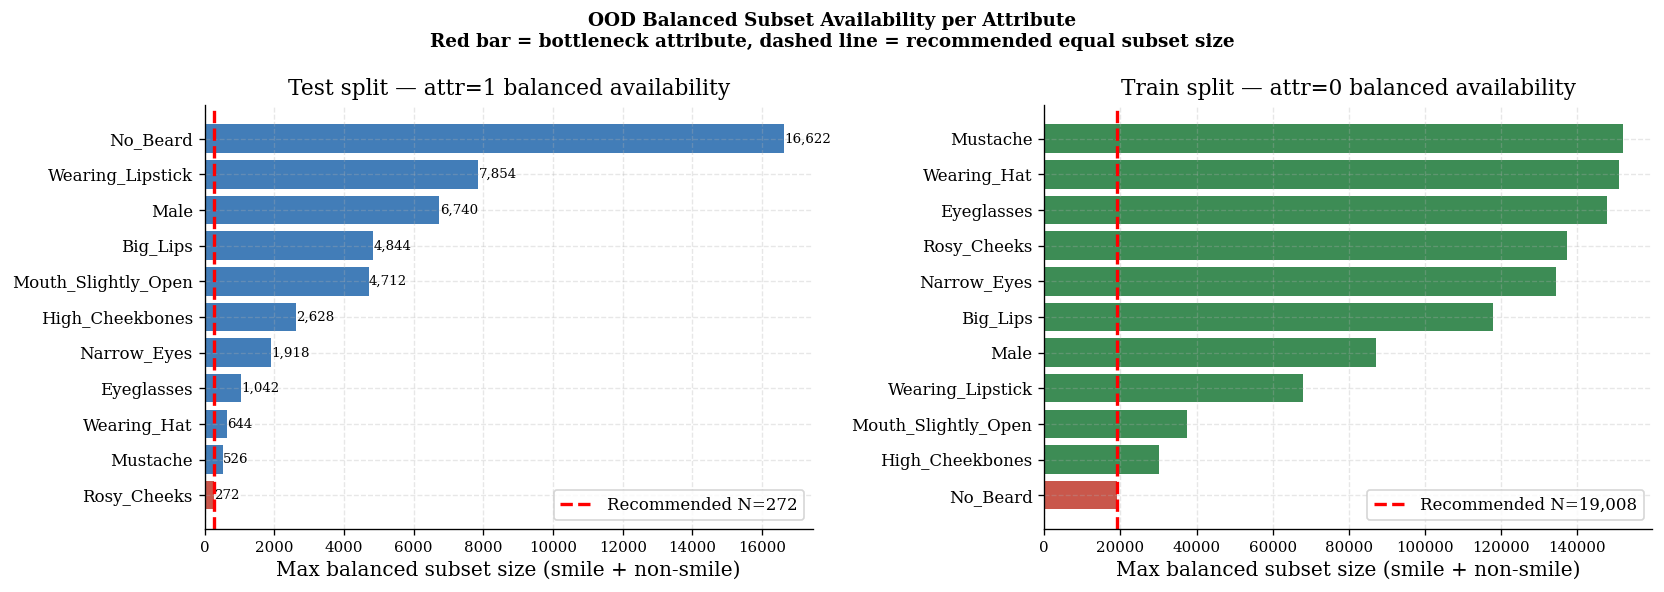


DATALOADER CONFIG RECOMMENDATION:
  ood_train_subset_per_class: 9504   # 19008 total train images per attr
  ood_test_subset_per_class:  136    # 272 total test  images per attr
  smile_balance: true          # 50/50 smile in both train and test subsets


In [4]:
## 8b. Visualize balanced subset availability per attribute

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

attrs_sorted_test  = subset_df.sort_values("Test max balanced")["Attribute"].tolist()
attrs_sorted_train = subset_df.sort_values("Train max balanced")["Attribute"].tolist()

# Panel 1: Test attr=1 — balanced pairs available
ax = axes[0]
vals = subset_df.set_index("Attribute").loc[attrs_sorted_test, "Test max balanced"]
colors = ['#c0392b' if v == vals.min() else '#2166ac' for v in vals]
ax.barh(attrs_sorted_test, vals * 2, color=colors, alpha=0.85)
ax.axvline(rec_test * 2, color='red', lw=2, ls='--', label=f'Recommended N={2*rec_test}')
ax.set_xlabel("Max balanced subset size (smile + non-smile)")
ax.set_title("Test split — attr=1 balanced availability")
ax.legend()
for i, v in enumerate(vals):
    ax.text(v*2 + 10, i, f"{v*2:,}", va='center', fontsize=8)

# Panel 2: Train attr=0 — balanced pairs available
ax = axes[1]
vals2 = subset_df.set_index("Attribute").loc[attrs_sorted_train, "Train max balanced"]
colors2 = ['#c0392b' if v == vals2.min() else '#1b7837' for v in vals2]
ax.barh(attrs_sorted_train, vals2 * 2, color=colors2, alpha=0.85)
ax.axvline(rec_train * 2, color='red', lw=2, ls='--', label=f'Recommended N={2*rec_train:,}')
ax.set_xlabel("Max balanced subset size (smile + non-smile)")
ax.set_title("Train split — attr=0 balanced availability")
ax.legend()

fig.suptitle("OOD Balanced Subset Availability per Attribute\n"
             "Red bar = bottleneck attribute, dashed line = recommended equal subset size",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_ood_subset_availability.pdf", bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"DATALOADER CONFIG RECOMMENDATION:")
print(f"{'='*60}")
print(f"  ood_train_subset_per_class: {rec_train}   # {2*rec_train} total train images per attr")
print(f"  ood_test_subset_per_class:  {rec_test}    # {2*rec_test} total test  images per attr")
print(f"  smile_balance: true          # 50/50 smile in both train and test subsets")
print(f"{'='*60}")

In [8]:
# Compact table for all OOD-feasible attributes — ready to paste into paper
paper_tbl = feasible_attrs[[
    "Attribute", "Attr=1 count", "% of split", "Smile", "Non-smile", "Smile %"
]].copy()
paper_tbl.columns = ["Attribute", "N (attr=1)", "% of test", "Smile", "Non-smile", "Smile %"]
paper_tbl = paper_tbl.sort_values("N (attr=1)", ascending=False).reset_index(drop=True)

print(f"OOD-feasible attributes: {len(paper_tbl)}")
display(paper_tbl.style.format({
    "N (attr=1)": "{:,}",
    "Smile":      "{:,}",
    "Non-smile":  "{:,}",
    "% of test":  "{:.1f}%",
    "Smile %":    "{:.1f}%",
}).bar(subset=["Smile %"], color=['#762a83', '#1b7837'], vmin=0, vmax=100))

# Print which OOD classifiers we trained
print("\nOOD attributes used in experiments:")
OOD_TRAINED = [
    "Wearing_Hat", "Eyeglasses", "Male", "Wearing_Lipstick",
    "Mouth_Slightly_Open", "High_Cheekbones", "Big_Lips",
    "Narrow_Eyes", "Mustache", "No_Beard", "Rosy_Cheeks"
]
sub = paper_tbl[paper_tbl["Attribute"].isin(OOD_TRAINED)]
display(sub.style.format({"N (attr=1)":"{:,}","Smile":"{:,}","Non-smile":"{:,}","Smile %":"{:.1f}%"}))

OOD-feasible attributes: 39


,Attribute,N (attr=1),% of test,Smile,Non-smile,Smile %
0,No_Beard,"16,943",83.6%,"8,632","8,311",50.9%
1,Young,"15,558",76.8%,"7,391","8,167",47.5%
2,Attractive,"10,265",50.7%,"5,783","4,482",56.3%
3,Mouth_Slightly_Open,"9,783",48.3%,"7,427","2,356",75.9%
4,Wearing_Lipstick,"9,515",47.0%,"5,588","3,927",58.7%
5,High_Cheekbones,"9,275",45.8%,"7,961","1,314",85.8%
6,Male,"8,452",41.7%,"3,370","5,082",39.9%
7,Heavy_Makeup,"7,808",38.5%,"4,697","3,111",60.2%
8,Wavy_Hair,"6,450",31.8%,"3,528","2,922",54.7%
9,Oval_Face,"5,732",28.3%,"3,733","1,999",65.1%



OOD attributes used in experiments:


,Attribute,N (attr=1),% of test,Smile,Non-smile,Smile %
0,No_Beard,"16,943",83.600000,"8,632","8,311",50.9%
3,Mouth_Slightly_Open,"9,783",48.300000,"7,427","2,356",75.9%
4,Wearing_Lipstick,"9,515",47.000000,"5,588","3,927",58.7%
5,High_Cheekbones,"9,275",45.800000,"7,961","1,314",85.8%
6,Male,"8,452",41.700000,"3,370","5,082",39.9%
13,Big_Lips,"4,847",23.900000,"2,422","2,425",50.0%
23,Narrow_Eyes,"2,301",11.400000,"1,342",959,58.3%
27,Rosy_Cheeks,"1,314",6.500000,"1,178",136,89.6%
28,Eyeglasses,"1,304",6.400000,521,783,40.0%
34,Wearing_Hat,970,4.800000,322,648,33.2%
